# Classificação Supervisionada com K-Means no Dataset Adult

Este notebook apresenta um experimento didático de classificação supervisionada utilizando o algoritmo K-Means no conjunto de dados Adult. O fluxo segue uma estrutura passo a passo, incluindo carregamento, pré-processamento, divisão dos dados, análise do número de clusters (método do cotovelo), implementação, treinamento, avaliação e análise dos resultados.

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, visualização e implementação do K-Means.

In [1]:
# 1. Importação das Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
import seaborn as sns
from sklearn.metrics import mean_squared_error
os.makedirs('img', exist_ok=True)

# Garante que a pasta 'img' existe
os.makedirs('img', exist_ok=True)

# 2. Carregamento e Pré-processamento dos Dados

Carregamos o dataset Adult, removemos valores ausentes, codificamos variáveis categóricas e normalizamos os dados. Também criamos a coluna binária do target.

In [2]:
# Visualização do dataset original (amostra)
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
print('Amostra dos dados originais:')
display(adult_df_raw.head())

Amostra dos dados originais:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


  income  income_bin
0  <=50K           0
7   >50K           1


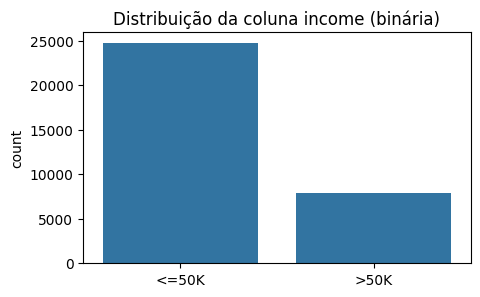

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_bin
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,<=50K,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,<=50K,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,<=50K,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,<=50K,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,<=50K,0


In [3]:
# Transformar income em valores binários explicitamente
def income_to_bin(val):
    return 1 if val.strip() == '>50K' else 0
adult_df_raw['income_bin'] = adult_df_raw['income'].apply(income_to_bin)
print(adult_df_raw[['income', 'income_bin']].drop_duplicates())

# Agora, continue o pré-processamento usando a coluna binária
adult_df = adult_df_raw.dropna().copy()
for col in adult_df.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df[col] = LabelEncoder().fit_transform(adult_df[col].astype(str))
X = adult_df.drop(['income', 'income_bin'], axis=1).values
y = adult_df['income_bin'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualizar distribuição binária após transformação
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title('Distribuição da coluna income (binária)')
plt.xticks([0,1],["<=50K",">50K"])
plt.show()

display(adult_df.head())

In [4]:
print(X)

[[ 0.03067056  2.15057856 -1.06361075 ... -0.21665953 -0.03542945
   0.29156857]
 [ 0.83710898  1.46373585 -1.008707   ... -0.21665953 -2.22215312
   0.29156857]
 [-0.04264203  0.09005041  0.2450785  ... -0.21665953 -0.03542945
   0.29156857]
 ...
 [ 1.42360965  0.09005041 -0.35877741 ... -0.21665953 -0.03542945
   0.29156857]
 [-1.21564337  0.09005041  0.11095988 ... -0.21665953 -1.65522476
   0.29156857]
 [ 0.98373415  0.77689313  0.92989258 ... -0.21665953 -0.03542945
   0.29156857]]


# 3. Divisão dos Dados em Treino e Teste

Dividimos o conjunto de dados em 70% para treinamento e 30% para teste, garantindo a estratificação das classes.

In [5]:
y_bin = y  # já está codificado como 0/1 após o LabelEncoder
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, random_state=42, stratify=y_bin)

# 4. Definição do Número de Clusters 

Utilize o notebook separado para o método do cotovelo e defina o valor de n_clusters abaixo conforme o resultado visualizado.

In [10]:
n_clusters = 10 # Ajuste conforme o método do cotovelo

# 5. Implementação do Classificador K-Means Supervisionado

O classificador associa cada cluster ao rótulo mais frequente no conjunto de treino.

In [11]:
class KMeansSupervisionado:
    def __init__(self, n_clusters=n_clusters, random_state=0):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.kmeans.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.kmeans.predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

# 6. Treinamento e Avaliação do Classificador

Treinamos o classificador no conjunto de treino e avaliamos no conjunto de teste, mostrando acurácia e matriz de confusão.

Acurácia: 0.7666
Matriz de Confusão:
[[7223  194]
 [2086  266]]


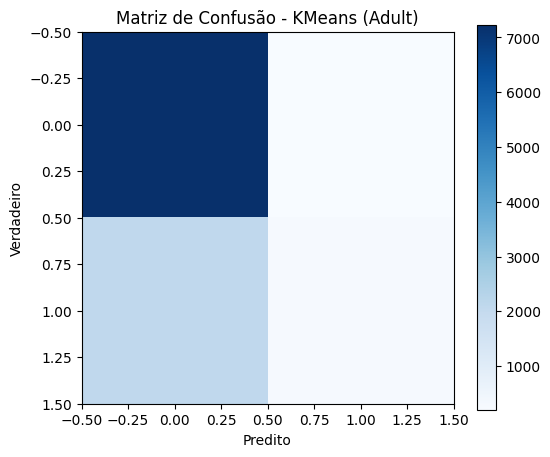

In [12]:
clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - KMeans (Adult)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/kmeans_adult_confusion_matrix.png')
plt.show()

# 7. Repetição dos Experimentos

Repita o experimento 30 vezes, variando a semente, e salve as acurácias para análise estatística.


Resumo das 30 repetições:
MSE médio: 0.2314
Desvio padrão do MSE: 0.0052
Acurácia média: 0.7686
Desvio padrão da acurácia: 0.0052


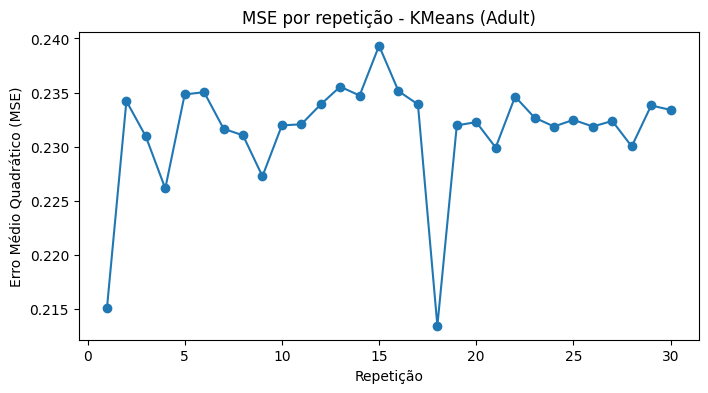

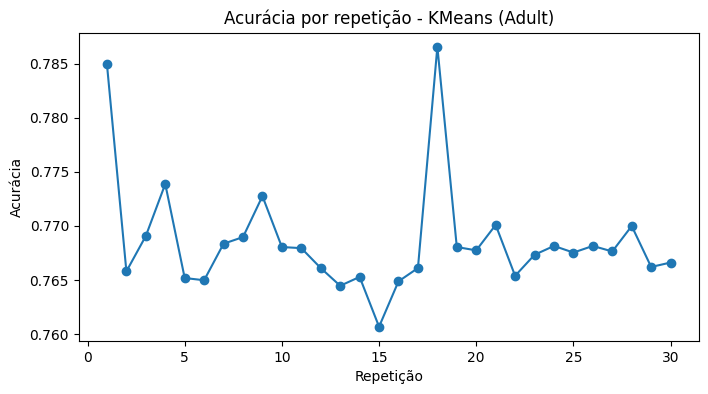

In [13]:
acuracias = []
mse_list = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_bin, test_size=0.3, random_state=seed, stratify=y_bin)
    clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)

acuracias = np.array(acuracias)
mse_array = np.array(mse_list)
print(f"\nResumo das 30 repetições:")
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - KMeans (Adult)')
plt.savefig('img/kmeans_adult_mse_repetitions.png')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - KMeans (Adult)')
plt.savefig('img/kmeans_adult_accuracy_repetitions.png')
plt.show()

# Salvar MSE e acurácias para análise posterior
np.save('img/kmeans_adult_mse_repetitions.npy', mse_array)
np.savetxt('img/kmeans_adult_mse_repetitions.csv', mse_array, delimiter=',')
np.save('img/kmeans_adult_accuracies.npy', acuracias)
np.savetxt('img/kmeans_adult_accuracies.csv', acuracias, delimiter=',')

# 8. Análise dos Resultados

Comente os resultados obtidos, destacando a acurácia média, o desvio padrão e possíveis dificuldades do classificador K-Means no dataset Adult.